# Virtual Analog Filters

The Moog ladder filter is one of the most influential analogue synthesis filter designs (R. Moog, 1965). Four cascaded one-pole RC sections with a resonant feedback path give a characteristic 24 dB/octave rolloff and a resonant peak that can be swept to self-oscillation.

This implementation uses the **Huovilainen approximation** (2004): a numerically efficient model that captures the nonlinear saturation of the original transistor ladder via `tanh` functions in the feedback path. For a linear-only ZDF model see `filters_ladder.ipynb`.

| Function | Description |
| --- | --- |
| `moog_ladder` | 4-pole ladder filter (Huovilainen approximation). Parameters: `cutoff` (Hz), `resonance` ∈ [0, 1]. At resonance → 1 the filter self-oscillates. Also available in `src/python/filters/ladder.py` as a ZDF model. |


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from python.generators import generate_impulse, generate_sine
from python.virtual_analog import moog_ladder

FS = 44100

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## Visualisation

Frequency and time-domain responses of the Huovilainen Moog ladder filter.

**2 × 2 grid:**

**Top-left — frequency response vs resonance (four values: 0 / 0.5 / 0.8 / 0.95), cutoff = 1 kHz:**
- −24 dB/octave slope above cutoff (four cascaded poles = −6 dB/oct each)
- Resonant peak grows with resonance; DC gain drops because the feedback network attenuates the passband
- At resonance = 0.95 the peak is very narrow and tall — near self-oscillation

**Top-right — frequency response vs cutoff (four values: 500 / 1k / 2k / 4 kHz), resonance = 0.7:**
- Identical steep slope at all cutoffs — the 4-pole character is preserved
- Tracking: the filter follows the `cutoff` parameter accurately across the full range

**Bottom-left — impulse response vs resonance:**
- Low resonance: fast decay, little ringing
- High resonance (0.95): long sustained oscillatory ring-down — the characteristic Moog "boing"

**Bottom-right — step response vs resonance:**
- The overshoot and oscillation on the step edge is the time-domain equivalent of the resonant peak
- DC steady-state level decreases with resonance due to the gain-reducing feedback path

Note: the Huovilainen model includes `tanh` in the feedback for nonlinear warmth; see `filters_ladder.ipynb` for the linear ZDF implementation.


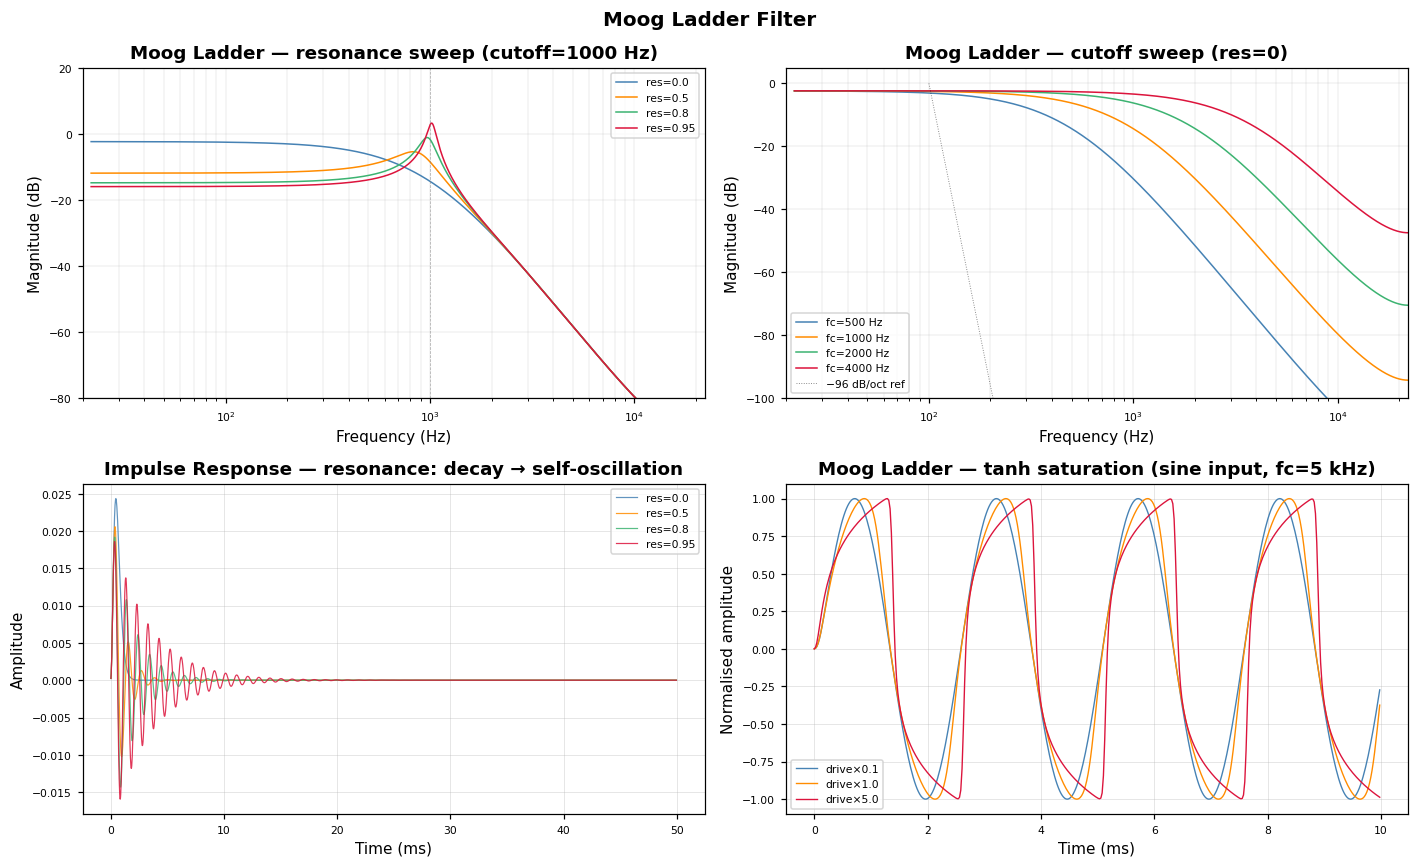

In [2]:
FS = 44100
DURATION = 0.5
CUTOFF = 1000.0

_, impulse = generate_impulse(fs=FS, duration=DURATION)


def _freq_response(h: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    freqs = np.fft.rfftfreq(len(h), d=1.0 / FS)
    db = 20 * np.log10(np.abs(np.fft.rfft(h)) + 1e-12)
    return freqs, db


RESONANCES = [0.0, 0.5, 0.8, 0.95]
CUTOFFS = [500.0, 1000.0, 2000.0, 4000.0]
COLORS = ["steelblue", "darkorange", "mediumseagreen", "crimson"]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Frequency response vs resonance
ax = axes[0, 0]
for res, color in zip(RESONANCES, COLORS):
    h = moog_ladder(impulse, cutoff=CUTOFF, fs=FS, resonance=res)
    freqs, db = _freq_response(h)
    mask = freqs > 20
    ax.semilogx(freqs[mask], db[mask], color=color, linewidth=1.0, label=f"res={res}")
ax.axvline(CUTOFF, color="gray", linewidth=0.5, linestyle="--", alpha=0.6)
ax.set_title(f"Moog Ladder — resonance sweep (cutoff={CUTOFF:.0f} Hz)", fontweight="bold")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude (dB)")
ax.set_xlim(20, FS / 2)
ax.set_ylim(-80, 20)
ax.legend(fontsize=7)
ax.grid(True, which="both", linewidth=0.3, alpha=0.5)

# Frequency response vs cutoff
ax = axes[0, 1]
for fc, color in zip(CUTOFFS, COLORS):
    h = moog_ladder(impulse, cutoff=fc, fs=FS, resonance=0.0)
    freqs, db = _freq_response(h)
    mask = freqs > 20
    ax.semilogx(freqs[mask], db[mask], color=color, linewidth=1.0, label=f"fc={fc:.0f} Hz")
# 24 dB/oct slope reference
ref_f = np.array([100, 20000])
ax.semilogx(ref_f, [0, -24 * 4 * np.log2(20000 / 100)], color="black", linewidth=0.6,
            linestyle=":", alpha=0.5, label="−96 dB/oct ref")
ax.set_title("Moog Ladder — cutoff sweep (res=0)", fontweight="bold")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude (dB)")
ax.set_xlim(20, FS / 2)
ax.set_ylim(-100, 5)
ax.legend(fontsize=7)
ax.grid(True, which="both", linewidth=0.3, alpha=0.5)

# Time-domain: self-oscillation at high resonance
_, short_imp = generate_impulse(fs=FS, duration=0.05)
t_ms = np.arange(len(short_imp)) / FS * 1000
ax = axes[1, 0]
for res, color in zip(RESONANCES, COLORS):
    h = moog_ladder(short_imp, cutoff=CUTOFF, fs=FS, resonance=res)
    ax.plot(t_ms, h, linewidth=0.8, color=color, label=f"res={res}", alpha=0.85)
ax.set_title("Impulse Response — resonance: decay → self-oscillation", fontweight="bold")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Amplitude")
ax.legend(fontsize=7)
ax.grid(True, linewidth=0.4, alpha=0.5)

# Sine input: waveform distortion from tanh nonlinearity
_, sine_sig = generate_sine(freq=400.0, fs=FS, duration=0.01)
t_ms_sine = np.arange(len(sine_sig)) / FS * 1000
ax = axes[1, 1]
for drive, color in [(0.1, "steelblue"), (1.0, "darkorange"), (5.0, "crimson")]:
    out = moog_ladder(sine_sig * drive, cutoff=5000.0, fs=FS, resonance=0.0)
    ax.plot(t_ms_sine, out / (max(abs(out)) + 1e-12), linewidth=0.9, color=color, label=f"drive×{drive}")
ax.set_title("Moog Ladder — tanh saturation (sine input, fc=5 kHz)", fontweight="bold")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Normalised amplitude")
ax.legend(fontsize=7)
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.tick_params(labelsize=7)

for ax in axes.flatten():
    ax.tick_params(labelsize=7)

fig.suptitle("Moog Ladder Filter", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()